In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_excel('penelitian_bersih.xlsx')
print("Shape data:", df.shape)

df.head()

Shape data: (305712, 18)


,namakecamatan,namakelurahan,baduta,balita,pus,pus_hamil,sumber_air_layak_tidak,jamban_layak_tidak,terlalu_muda,terlalu_tua,terlalu_dekat,terlalu_banyak,bukan_peserta_kb_modern,risiko_stunting,kesejahteraan_prioritas,Tahun,lat,lon
0,BOGOR BARAT,MARGA JAYA,V,X,X,V,2,X,X,X,X,X,X,0,9,2023,-6.570585,106.740801
1,BOGOR TENGAH,BABAKAN,V,V,X,X,2,X,V,X,X,X,X,0,9,2023,-6.589334,106.805437
2,BOGOR TENGAH,BABAKAN,V,V,V,X,2,X,X,X,X,X,X,0,9,2023,-6.589334,106.805437
3,BOGOR TENGAH,PALEDANG,V,X,V,X,2,V,V,X,X,X,X,1,9,2023,-6.599133,106.792007
4,BOGOR SELATAN,KERTAMAYA,X,V,X,V,2,X,X,X,X,X,X,0,9,2023,-6.649966,106.830969


In [3]:
target_cols = [
    'baduta',
    'balita',
    'pus',
    'pus_hamil',
    'sumber_air_layak_tidak',
    'jamban_layak_tidak',
    'terlalu_muda',
    'terlalu_tua',
    'terlalu_dekat',
    'terlalu_banyak',
    'bukan_peserta_kb_modern',
    'kesejahteraan_prioritas'
]
y_col = 'risiko_stunting'

In [4]:
binary_cols = [
    'baduta','balita','pus','pus_hamil','jamban_layak_tidak',
    'terlalu_muda','terlalu_tua','terlalu_dekat','terlalu_banyak',
    'bukan_peserta_kb_modern'
]

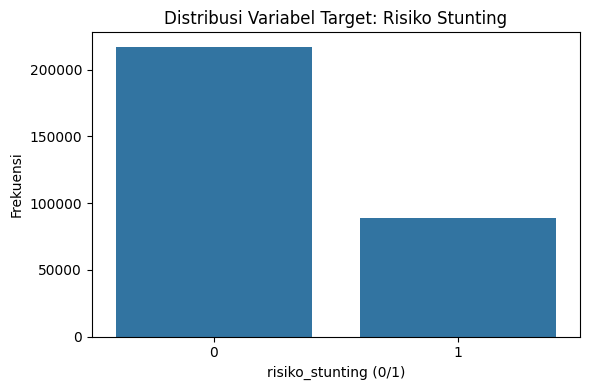

In [5]:
df_eda = df.copy()

plt.figure(figsize=(6,4))
sns.countplot(x=y_col, data=df_eda)
plt.title('Distribusi Variabel Target: Risiko Stunting')
plt.xlabel('risiko_stunting (0/1)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Proporsi Risiko Stunting (%):


,count,percent
risiko_stunting,,
0,216989,70.98
1,88723,29.02


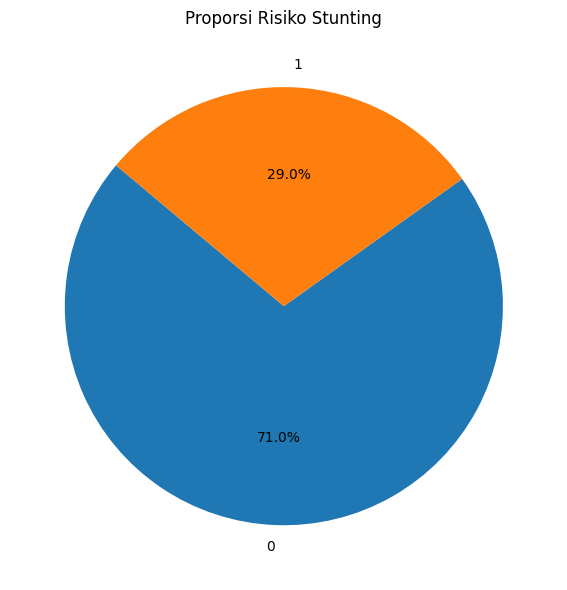

In [6]:
y_counts = df_eda[y_col].value_counts(dropna=False)
y_pct = (y_counts / y_counts.sum()) * 100
print("Proporsi Risiko Stunting (%):")
display(pd.DataFrame({'count': y_counts, 'percent': y_pct.round(2)}))

plt.figure(figsize=(6,6))
plt.pie(y_pct.values, labels=y_pct.index, autopct='%1.1f%%', startangle=140)
plt.title('Proporsi Risiko Stunting')
plt.tight_layout()
plt.show()

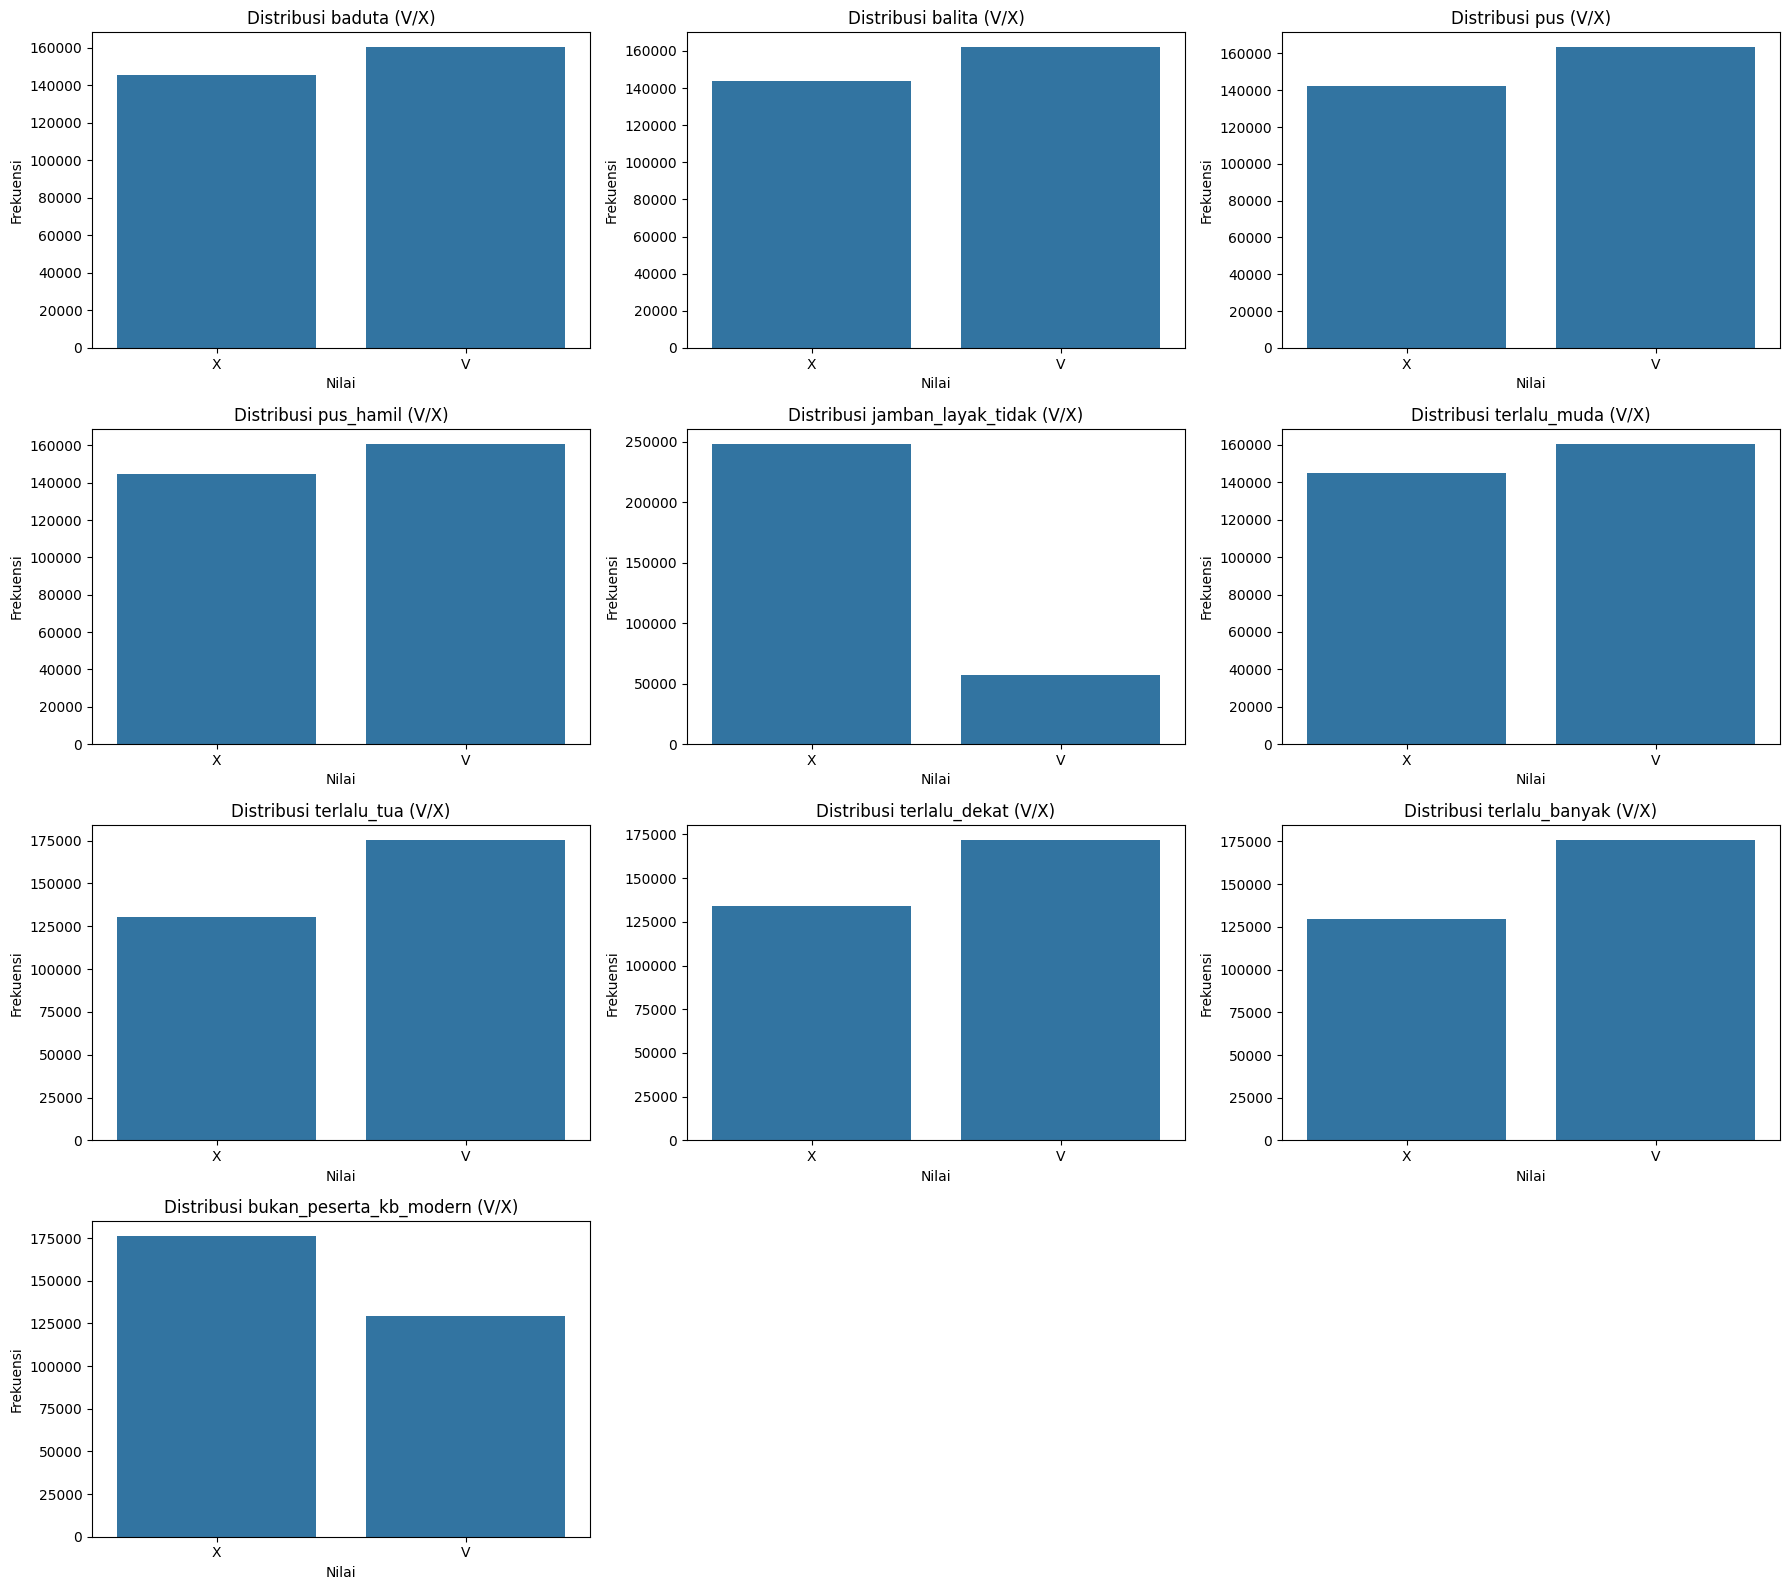

In [7]:
n_cols = 3
n_rows = math.ceil(len(binary_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    if col in df_eda.columns:
        sns.countplot(x=col, data=df_eda, ax=axes[i], order=['X','V'])
        axes[i].set_title(f'Distribusi {col} (V/X)')
        axes[i].set_xlabel('Nilai')
        axes[i].set_ylabel('Frekuensi')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


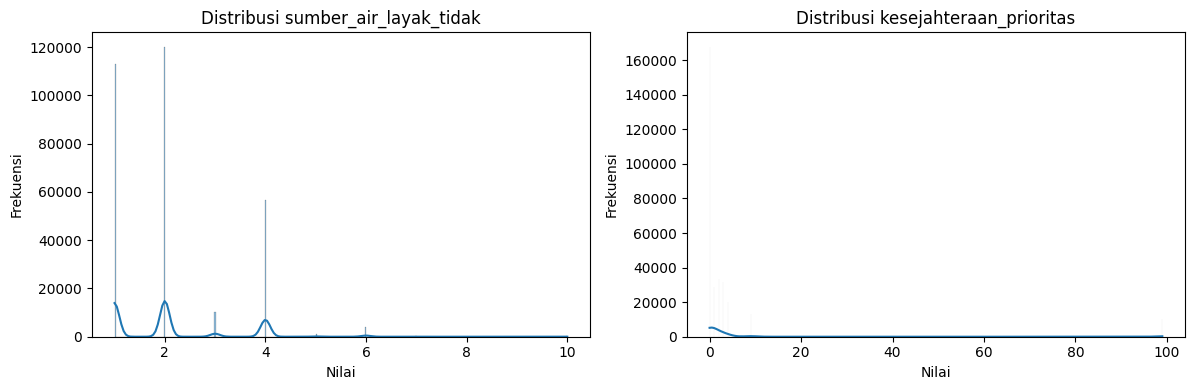

In [8]:
numeric_cols = [c for c in target_cols if c not in binary_cols]
if len(numeric_cols) > 0:
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.histplot(df_eda[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribusi {col}')
        axes[i].set_xlabel('Nilai')
        axes[i].set_ylabel('Frekuensi')
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

C:\Users\DK\AppData\Local\Temp\ipykernel_15200\533319258.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr = df_corr.replace({'X':0,'V':1,'x':0,'v':1,'VV':1})


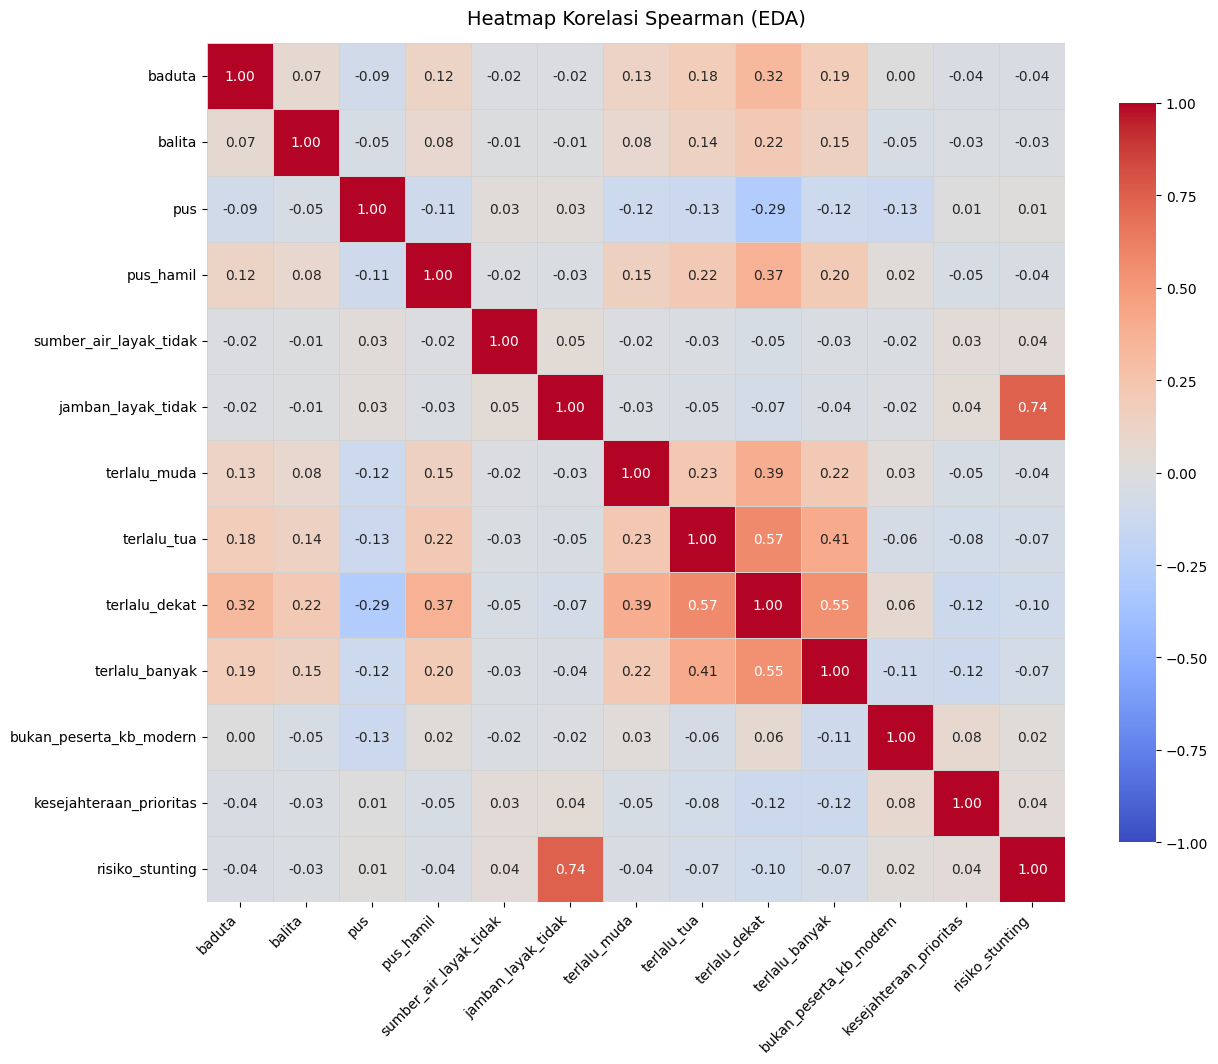

In [9]:
df_corr = df_eda[target_cols + [y_col]].copy()
df_corr = df_corr.replace({'X':0,'V':1,'x':0,'v':1,'VV':1})
for col in target_cols + [y_col]:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')
df_corr = df_corr.dropna(subset=target_cols + [y_col])

corr_matrix = df_corr[target_cols + [y_col]].corr(method='spearman')

plt.figure(figsize=(13,11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='lightgray',
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Spearman (EDA)', fontsize=14, pad=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

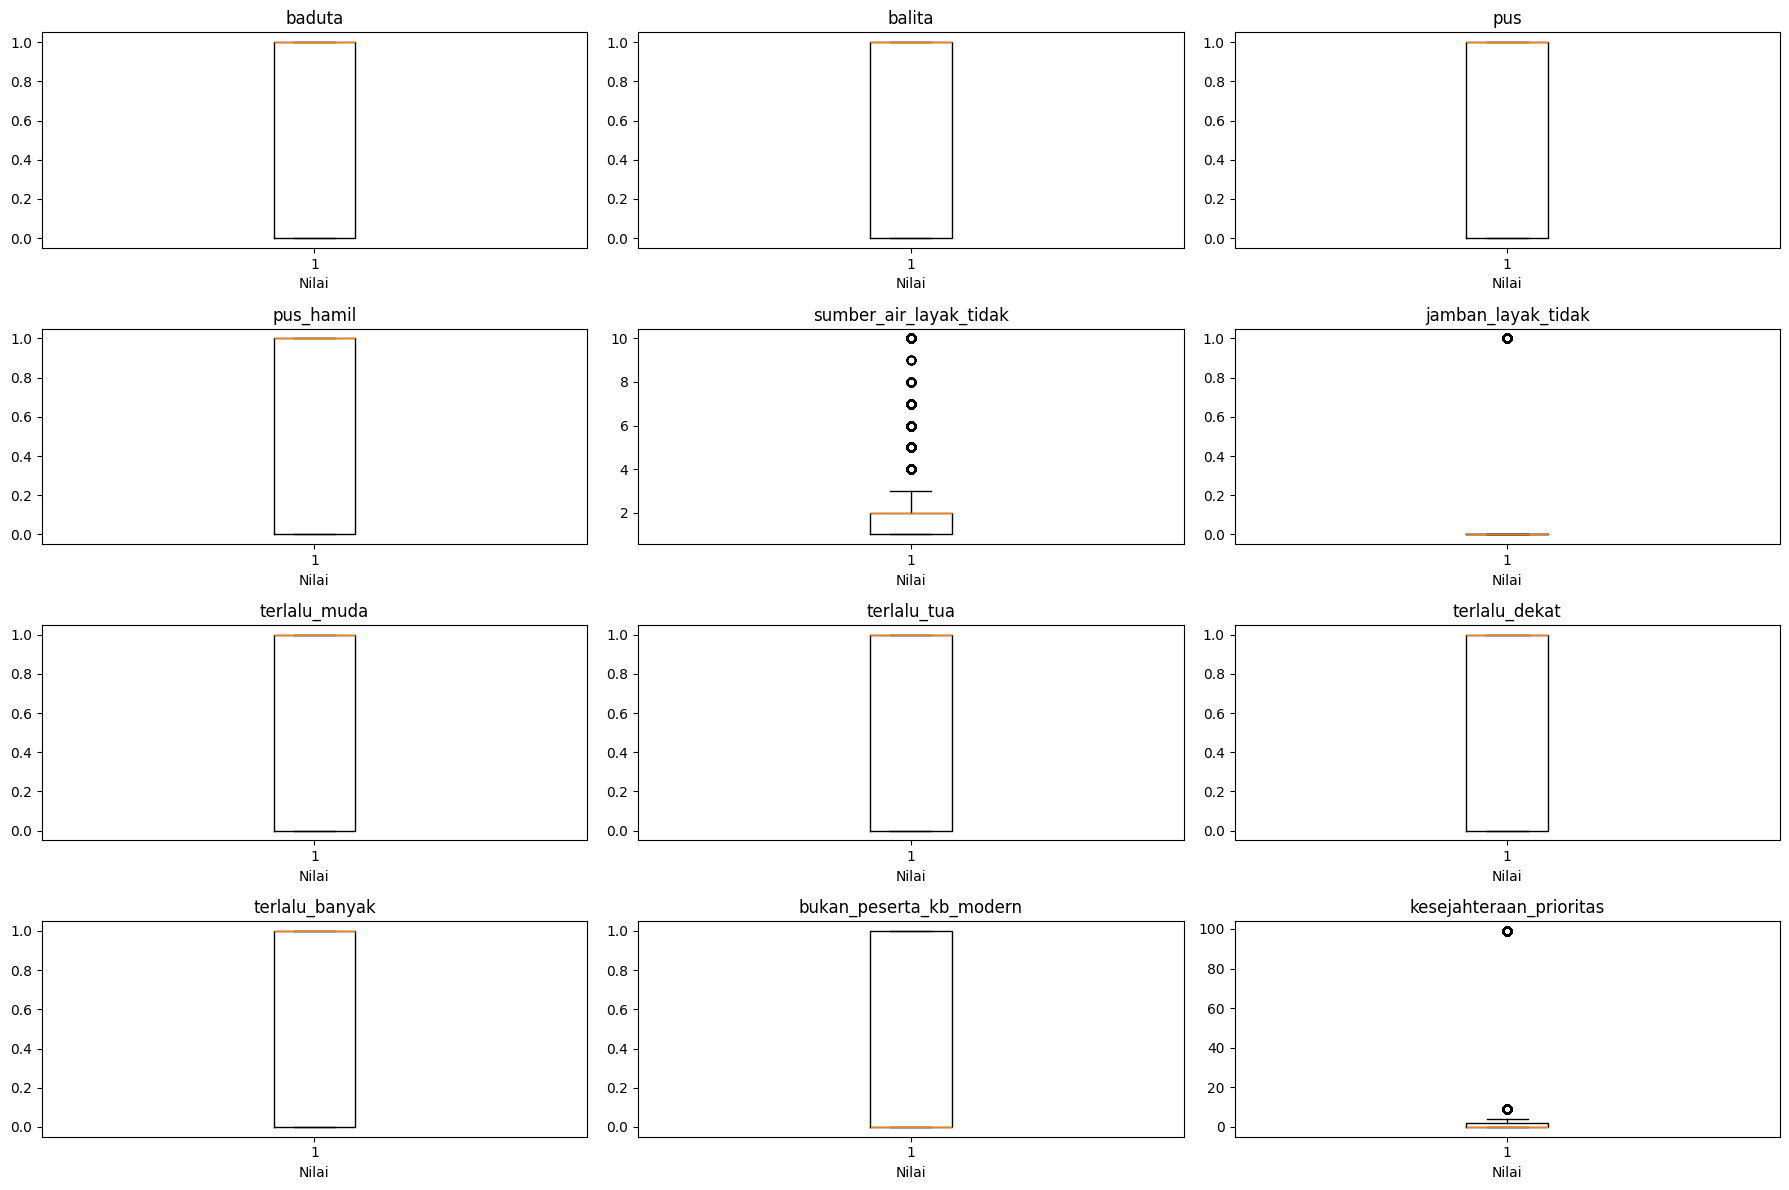

In [10]:
plt.figure(figsize=(18,12))
for i, col in enumerate(target_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df_corr[col].dropna())
    plt.title(f'{col}')
    plt.xlabel('Nilai')
plt.tight_layout()
plt.show()

In [11]:
df_iqr_vis = df_corr.copy()
for col in target_cols:
    Q1 = df_iqr_vis[col].quantile(0.25)
    Q3 = df_iqr_vis[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_iqr_vis[col] = df_iqr_vis[col].clip(lower, upper)

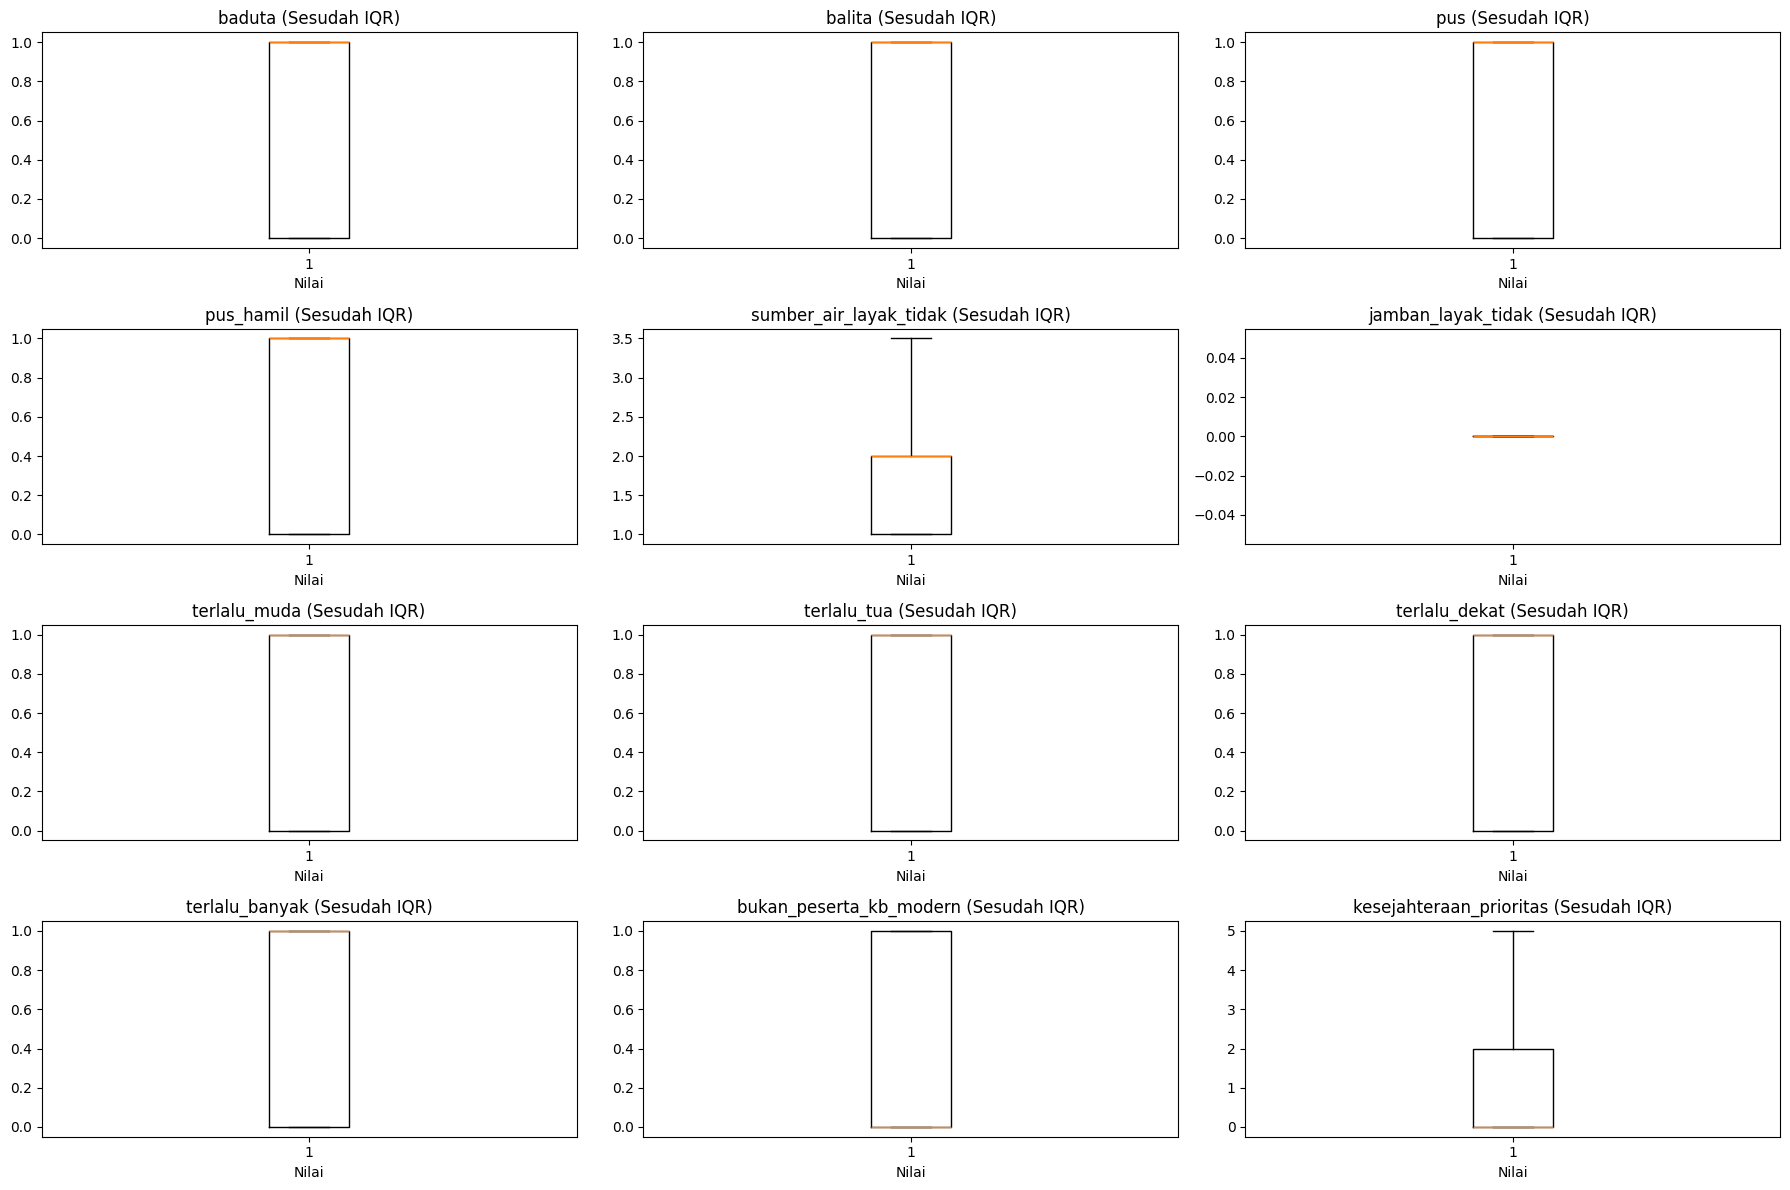

In [12]:
plt.figure(figsize=(18,12))
for i, col in enumerate(target_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df_iqr_vis[col].dropna())
    plt.title(f'{col} (Sesudah IQR)')
    plt.xlabel('Nilai')
plt.tight_layout()
plt.show()

In [13]:
df_clean = df.copy()

df_clean = df_clean.drop(
    columns=['namakecamatan', 'namakelurahan', 'Tahun', 'lat', 'lon'],
    errors='ignore'
)

In [14]:
df_clean = df_clean.replace({'X':0,'V':1,'x':0,'v':1,'VV':1})
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

C:\Users\DK\AppData\Local\Temp\ipykernel_15200\3160989684.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df_clean.replace({'X':0,'V':1,'x':0,'v':1,'VV':1})


In [15]:
df_clean = df_clean.dropna(subset=target_cols + [y_col])

df_clean[y_col] = (df_clean[y_col] > 0).astype(int)

print("Shape setelah cleaning:", df_clean.shape)
print("Distribusi y:\n", df_clean[y_col].value_counts())


Shape setelah cleaning: (305712, 13)
Distribusi y:
 risiko_stunting
0    216989
1     88723
Name: count, dtype: int64


In [16]:
X = df_clean[target_cols].copy()
y = df_clean[y_col].copy()

In [17]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
mask_outlier = ~((X < (Q1 - 1.5*IQR)) | (X > (Q3 + 1.5*IQR))).any(axis=1)

X = X.loc[mask_outlier].copy()
y = y.loc[mask_outlier].copy()

In [18]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.values,
    test_size=0.2,
    random_state=42,
    stratify=y.values
)

In [20]:
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm  = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("Train:", X_train_lstm.shape)
print("Test :", X_test_lstm.shape)

Train: (145411, 1, 12)
Test : (36353, 1, 12)


In [21]:
model = Sequential()
model.add(Input(shape=(1, X_train.shape[1])))

model.add(Bidirectional(LSTM(256, return_sequences=True)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.build(input_shape=(None, 1, X_train.shape[1]))

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 512)         │       550,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1, 256)         │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,382,017 (5.27 MB)

 Trainable params: 1,382,017 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.8662 - auc: 0.5753 - loss: 0.4151 - val_accuracy: 0.8660 - val_auc: 0.7215 - val_loss: 0.3658 - learning_rate: 5.0000e-04
Epoch 2/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9500 - auc: 0.9615 - loss: 0.1454 - val_accuracy: 0.9919 - val_auc: 0.9854 - val_loss: 0.0503 - learning_rate: 5.0000e-04
Epoch 3/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9903 - auc: 0.9812 - loss: 0.0541 - val_accuracy: 0.9920 - val_auc: 0.9848 - val_loss: 0.0438 - learning_rate: 5.0000e-04
Epoch 4/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9907 - auc: 0.9822 - loss: 0.0487 - val_accuracy: 0.9922 - val_auc: 0.9854 - val_loss: 0.0410 - learning_rate: 5.0000e-04
Epoch 5/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9908 - auc: 0.9825 - loss: 0.0456 - val_accuracy: 0.9922 - val_auc: 0.9879 - val_loss: 0.0396 - learning_rate: 5.0000e-04
Epoch 6/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/

In [23]:
loss, acc, auc = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f"Akurasi Uji: {acc:.4f}")
print(f"AUC Uji    : {auc:.4f}")

y_prob = model.predict(X_test_lstm).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Akurasi Uji: 0.9906
AUC Uji    : 0.9886
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     31576
           1       0.97      0.96      0.96      4777

    accuracy                           0.99     36353
   macro avg       0.98      0.98      0.98     36353
weighted avg       0.99      0.99      0.99     36353

Confusion Matrix:
 [[31425   151]
 [  192  4585]]


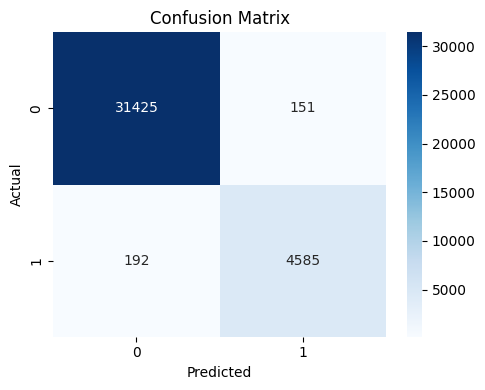

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

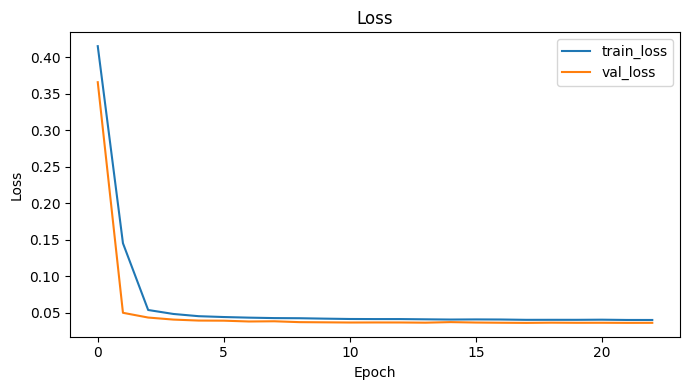

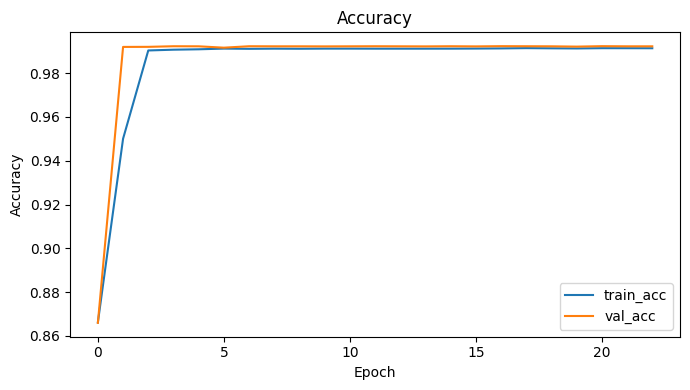

In [25]:
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
model.save('model_bilstm512.h5')

with open('history_bilstm512.pkl', 'wb') as f:
    pickle.dump(history.history, f)

with open('data_test_bilstm512.pkl', 'wb') as f:
    pickle.dump((X_test, y_test), f)

with open('scaler_bilstm512.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ SELESAI!")

✅ SELESAI!
